
# **Análise de Risco de Inadimplência**



# **Tópicos**

1.   Descrição;
2.   Importação de Bibliotecas;
3.   Download, Carregamento e Geração dos dados;
4.   Exploração;
5.   Limpeza e Transformação;
6.   Análise e Visualizações;
7.   Resumo dos insights gerados;




## **1. Descrição**


Realizar Análise de risco de Inadimplência entre clientes de uma instituição financeira.


## **2. Importação de Bibliotecas**


Importação das principais bibliotecas utilizadas no projeto.


In [41]:
#pandas: biblioteca utilizada para manipulação dos dados
import pandas as pd
#seaborn e matplotlib: bibliotecas utilizadas na visualização gráfica.
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## **3. Download, Carregamento e Geração dos dados**

In [ ]:
# Base de dados disponibilizada pelo professor André, fonte remota: https://raw.githubusercontent.com/andre-marcos-perez/ebac-course-utils/develop/dataset/credito.csv

df = pd.read_csv('credito.csv', na_values='na')

In [4]:
df.head()

,id,default,idade,sexo,dependentes,escolaridade,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m
0,768805383,0,45,M,3,ensino medio,casado,$60K - $80K,blue,39,5,3,1,"12.691,51","1.144,90",42
1,818770008,0,49,F,5,mestrado,solteiro,menos que $40K,blue,44,6,2,1,"8.256,96","1.291,45",33
2,713982108,0,51,M,3,mestrado,casado,$80K - $120K,blue,36,4,0,1,"3.418,56","1.887,72",20
3,769911858,0,40,F,4,ensino medio,NaN,menos que $40K,blue,34,3,1,4,"3.313,03","1.171,56",20
4,709106358,0,40,M,3,sem educacao formal,casado,$60K - $80K,blue,21,5,0,1,"4.716,22","816,08",28


## **4. Exploração**



Nessa etapa vamos explorar os dados de crédito de clientes de uma instituição financeira. Em especial, estamos interessados em explicar a segunda coluna, chamada de default, que indica se um cliente é adimplente(default = 0), ou inadimplente (default = 1).



In [5]:
# retorna total de qtd linhas e qtd colunas
df.shape


(10127, 16)

In [5]:
#Adimplentes - qtd linhas e qtd colunas
df[df['default'] == 0].shape

(8500, 16)

In [6]:
#Inadimplentes - qtd linhas e qtd colunas
df[df['default'] == 1].shape

(1627, 16)

In [6]:
qtd_total, _ = df.shape
qtd_adimplentes, _ = df[df['default'] == 0].shape
qtd_inadimplentes, _ = df[df['default'] == 1].shape

print(f"A proporcão clientes adimplentes é de {round(100 * qtd_adimplentes / qtd_total, 2)}%")
print(f"A proporcão clientes inadimplentes é de {round(100 * qtd_inadimplentes / qtd_total, 2)}%")


A proporcão clientes adimplentes é de 83.93%
A proporcão clientes inadimplentes é de 16.07%


### **4.1 Exploração da Estrutura**

Com o dados em mãos, vamos conhecer um pouco melhor a estrutura do nosso conjunto de dados.

In [7]:
# retorna o tipo de dado de cada coluna
df.dtypes

id                         int64
default                    int64
idade                      int64
sexo                         str
dependentes                int64
escolaridade                 str
estado_civil                 str
salario_anual                str
tipo_cartao                  str
meses_de_relacionamento    int64
qtd_produtos               int64
iteracoes_12m              int64
meses_inativo_12m          int64
limite_credito               str
valor_transacoes_12m         str
qtd_transacoes_12m         int64
dtype: object


*   Atributos **Categóricos**




In [11]:
df.select_dtypes('str').describe().transpose()

,count,unique,top,freq
sexo,10127,2,F,5358
escolaridade,8608,5,mestrado,3128
estado_civil,9378,3,casado,4687
salario_anual,9015,5,menos que $40K,3561
tipo_cartao,10127,4,blue,9436
limite_credito,10127,9272,"1.438,21",11
valor_transacoes_12m,10127,10035,"1.388,72",3


> Nesse primeiro momento descobrimos que será necessário realizar uma alteração no tipo de dados das colunas **limite_credito** e **valor_transacoes_12m**, ambas estão definidas com o tipo de dados string, com isso são retornadas como valores categóricos (dtype = object).
Deve ser convertido para float, já que representa valores monetários.






*   Atributos **Númericos**




In [12]:
df.drop('id', axis=1).select_dtypes('number').describe().transpose()

,count,mean,std,min,25%,50%,75%,max
default,10127.0,0.160660,0.367235,0.0,0.0,0.0,0.0,1.0
idade,10127.0,46.325960,8.016814,26.0,41.0,46.0,52.0,73.0
dependentes,10127.0,2.346203,1.298908,0.0,1.0,2.0,3.0,5.0
meses_de_relacionamento,10127.0,35.928409,7.986416,13.0,31.0,36.0,40.0,56.0
qtd_produtos,10127.0,3.812580,1.554408,1.0,3.0,4.0,5.0,6.0
iteracoes_12m,10127.0,2.455317,1.106225,0.0,2.0,2.0,3.0,6.0
meses_inativo_12m,10127.0,2.341167,1.010622,0.0,2.0,2.0,3.0,6.0
qtd_transacoes_12m,10127.0,64.858695,23.472570,10.0,45.0,67.0,81.0,139.0


### **4.2 Exploração Dados Faltantes**

In [14]:
# retorna quais colunas possuem dados faltantes
df.isna().any()

id                         False
default                    False
idade                      False
sexo                       False
dependentes                False
escolaridade                True
estado_civil                True
salario_anual               True
tipo_cartao                False
meses_de_relacionamento    False
qtd_produtos               False
iteracoes_12m              False
meses_inativo_12m          False
limite_credito             False
valor_transacoes_12m       False
qtd_transacoes_12m         False
dtype: bool

> Descobrimos que as colunas **escolaridade**, **estado_civil** e **salario_anual**, possuem dados nulos.

> Na função abaixo conseguimos visualizar algumas estatisticas sobre as colunas com dados faltantes:

In [15]:
def stats_dados_faltantes(df: pd.DataFrame) -> None:

  stats_dados_faltantes = []
  for col in df.columns:
    if df[col].isna().any():
      qtd, _ = df[df[col].isna()].shape
      total, _ = df.shape
      dict_dados_faltantes = {col: {'quantidade': qtd, "porcentagem": round(100 * qtd/total, 2)}}
      stats_dados_faltantes.append(dict_dados_faltantes)

  for stat in stats_dados_faltantes:
    print(stat)

In [16]:
# Apresenta o total de dados faltantes
stats_dados_faltantes(df=df)

{'escolaridade': {'quantidade': 1519, 'porcentagem': 15.0}}
{'estado_civil': {'quantidade': 749, 'porcentagem': 7.4}}
{'salario_anual': {'quantidade': 1112, 'porcentagem': 10.98}}


In [17]:
# Apresenta os dados faltantes somente dos clientes Adimplentes
stats_dados_faltantes(df=df[df['default'] == 0])

{'escolaridade': {'quantidade': 1263, 'porcentagem': 14.86}}
{'estado_civil': {'quantidade': 620, 'porcentagem': 7.29}}
{'salario_anual': {'quantidade': 925, 'porcentagem': 10.88}}


In [18]:
# Apresenta os dados faltantes somente dos clientes Inadimplentes
stats_dados_faltantes(df=df[df['default'] == 1])

{'escolaridade': {'quantidade': 256, 'porcentagem': 15.73}}
{'estado_civil': {'quantidade': 129, 'porcentagem': 7.93}}
{'salario_anual': {'quantidade': 187, 'porcentagem': 11.49}}


## **5. Limpeza e Transformação**



Agora que conhecemos melhor a natureza do nosso conjunto de dados, vamos realizar uma atividade conhecida como **data wrangling** que consiste na transformação e limpeza dos dados para que possam ser melhor analisados.
Em especial, vamos trabalhar os seguintes itens:

 *   Corrigir o schema das colunas;
 *   Remover os dados faltantes.






### **5.1  Correção de schema**

In [19]:
df[['limite_credito', 'valor_transacoes_12m']].dtypes

limite_credito          str
valor_transacoes_12m    str
dtype: object

In [20]:
df[['limite_credito', 'valor_transacoes_12m']].head(n=5)

,limite_credito,valor_transacoes_12m
0,"12.691,51","1.144,90"
1,"8.256,96","1.291,45"
2,"3.418,56","1.887,72"
3,"3.313,03","1.171,56"
4,"4.716,22","816,08"


Vamos criar uma função lambda para limpar os dados e transformar para float os valores das colunas limite_credito e valor_transacoes_12m.

In [21]:
fn = lambda valor: float(valor.replace(".", "").replace(",", "."))

df['limite_credito'] = list(map(fn, df['limite_credito']))
df['valor_transacoes_12m'] = list(map(fn, df['valor_transacoes_12m']))


In [22]:
df[['limite_credito', 'valor_transacoes_12m']].head(n=5)

,limite_credito,valor_transacoes_12m
0,12691.51,1144.90
1,8256.96,1291.45
2,3418.56,1887.72
3,3313.03,1171.56
4,4716.22,816.08


Vamos visualizar novamente o schema:

In [23]:
df.dtypes

id                           int64
default                      int64
idade                        int64
sexo                           str
dependentes                  int64
escolaridade                   str
estado_civil                   str
salario_anual                  str
tipo_cartao                    str
meses_de_relacionamento      int64
qtd_produtos                 int64
iteracoes_12m                int64
meses_inativo_12m            int64
limite_credito             float64
valor_transacoes_12m       float64
qtd_transacoes_12m           int64
dtype: object

* Atributos **categóricos**:




In [26]:
df.select_dtypes('str').describe().transpose()

,count,unique,top,freq
sexo,10127,2,F,5358
escolaridade,8608,5,mestrado,3128
estado_civil,9378,3,casado,4687
salario_anual,9015,5,menos que $40K,3561
tipo_cartao,10127,4,blue,9436


* Atributos **númericos**:

In [27]:
df.drop('id', axis=1).select_dtypes('number').describe().transpose()

,count,mean,std,min,25%,50%,75%,max
default,10127.0,0.160660,0.367235,0.00,0.000,0.00,0.000,1.00
idade,10127.0,46.325960,8.016814,26.00,41.000,46.00,52.000,73.00
dependentes,10127.0,2.346203,1.298908,0.00,1.000,2.00,3.000,5.00
meses_de_relacionamento,10127.0,35.928409,7.986416,13.00,31.000,36.00,40.000,56.00
qtd_produtos,10127.0,3.812580,1.554408,1.00,3.000,4.00,5.000,6.00
iteracoes_12m,10127.0,2.455317,1.106225,0.00,2.000,2.00,3.000,6.00
meses_inativo_12m,10127.0,2.341167,1.010622,0.00,2.000,2.00,3.000,6.00
limite_credito,10127.0,8632.440165,9088.788041,1438.00,2555.355,4549.42,11068.175,34516.99
valor_transacoes_12m,10127.0,4404.583047,3397.128078,510.16,2155.825,3899.59,4741.310,18484.93
qtd_transacoes_12m,10127.0,64.858695,23.472570,10.00,45.000,67.00,81.000,139.00


### **5.2  Remoção de dados faltantes**

In [28]:
df.dropna(inplace=True)

In [29]:
qtd_total_novo, _ = df.shape
qtd_adimplentes_novo, _ = df[df['default'] == 0].shape
qtd_inadimplentes_novo, _ = df[df['default'] == 1].shape

In [30]:
print(f"A proporcão adimplentes ativos é de {round(100 * qtd_adimplentes / qtd_total, 2)}%")
print(f"A nova proporcão de clientes adimplentes é de {round(100 * qtd_adimplentes_novo / qtd_total_novo, 2)}%")
print("")
print(f"A proporcão clientes inadimplentes é de {round(100 * qtd_inadimplentes / qtd_total, 2)}%")
print(f"A nova proporcão de clientes inadimplentes é de {round(100 * qtd_inadimplentes_novo / qtd_total_novo, 2)}%")

A proporcão adimplentes ativos é de 83.93%
A nova proporcão de clientes adimplentes é de 84.28%

A proporcão clientes inadimplentes é de 16.07%
A nova proporcão de clientes inadimplentes é de 15.72%


## **6. Análise e Visualizações**



Agora com os dados prontos, podemos criar visualizações para correlacionar variáveis, buscando entender qual fator leva um cliente a inadimplencia.

Começamos separando os clientes adimplentes e inadimplentes.






In [31]:
df_adimplente = df[df['default'] == 0]

In [32]:
df_inadimplente = df[df['default'] == 1]


*   **Proporção de Clientes**




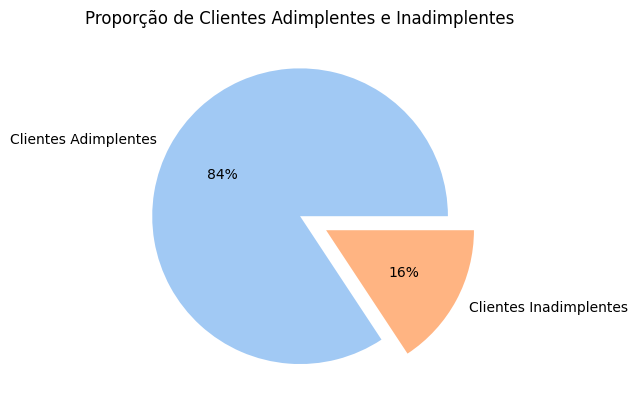

In [33]:
data = [qtd_adimplentes_novo, qtd_inadimplentes_novo]
keys = ['Clientes Adimplentes', 'Clientes Inadimplentes']

palette_color = sns.color_palette('pastel')
plt.pie(data, labels=keys, colors=palette_color, explode=[0, 0.2], autopct='%.0f%%')
plt.title('Proporção de Clientes Adimplentes e Inadimplentes')
plt.show()

### **6.1 Visualizações Categóricas**




Nessa etapa vamos visualizar a relação entre a variável resposta default com os atributos categóricos.



*   **Inadimplentes por sexo**




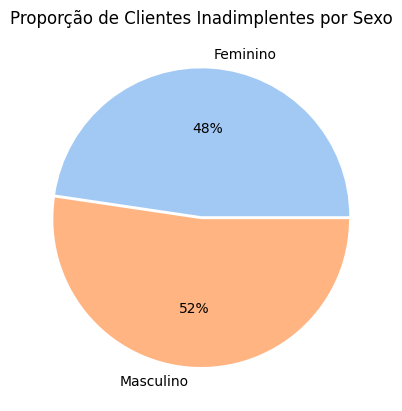

In [34]:

qtd_inadimplentes_f, _ = df[df['sexo'] == 'F'].shape
qtd_inadimplentes_m, _ = df[df['sexo'] == 'M'].shape
data = [qtd_inadimplentes_f, qtd_inadimplentes_m]
keys = ['Feminino', 'Masculino']

palette_color = sns.color_palette('pastel')
plt.pie(data, labels=keys, colors=palette_color, explode=[0, 0.02], autopct='%.0f%%')
plt.title('Proporção de Clientes Inadimplentes por Sexo')
plt.show()



> Os dados nos mostram que a maior parte dos clientes inadimplentes são do sexo masculino 52%.




*   **Salário Anual**




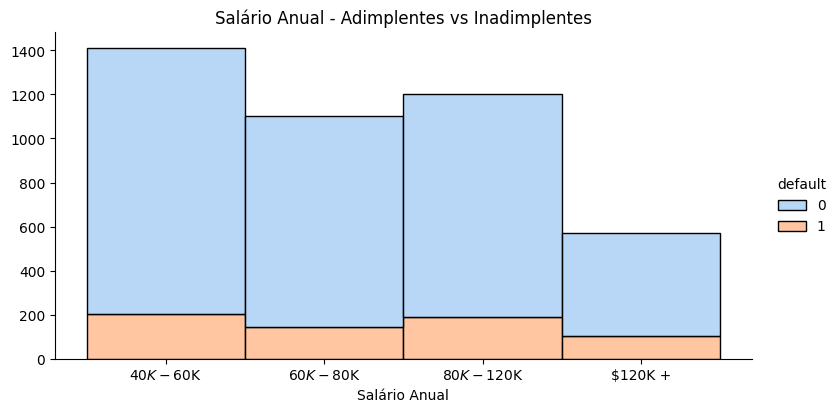

In [42]:
sns.set_palette("pastel")

ordem               = ['menor que $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +']
df['salario_anual'] = pd.Categorical(df['salario_anual'], categories=ordem, ordered=True)

sns.displot(data=df, x='salario_anual', hue='default', multiple='stack', height=4, aspect=2)
plt.xlabel('Salário Anual')
plt.ylabel('')
plt.title('Salário Anual - Adimplentes vs Inadimplentes')
plt.show()



> Quanto ao salário anual, identificamos que não existem variações expressivas que possam determinar um padrão de comportamento.






*   **Escolaridade**




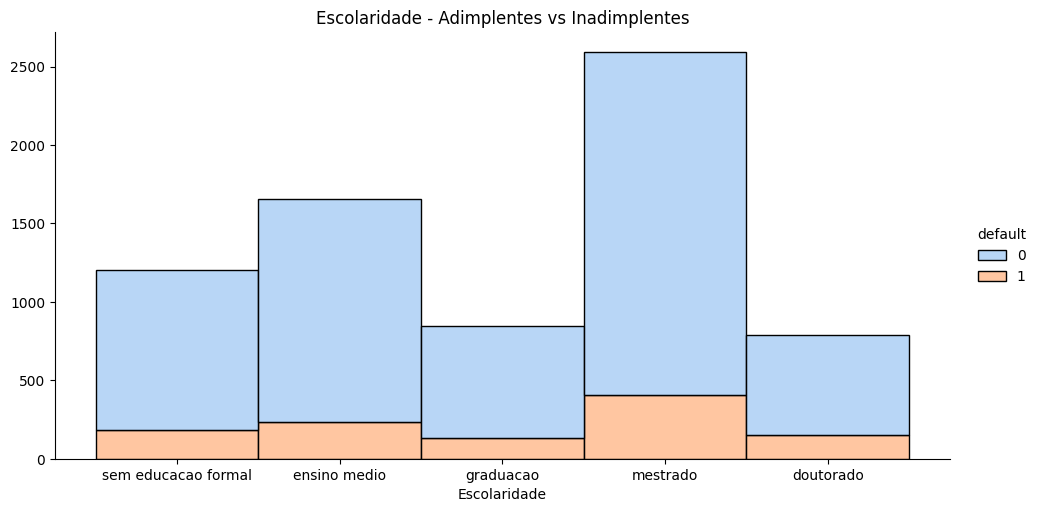

In [36]:
sns.set_palette("pastel")

ordem               = ['sem educacao formal', 'ensino medio', 'graduacao', 'mestrado', 'doutorado', 'nao informado']
df['escolaridade'] = pd.Categorical(df['escolaridade'], categories=ordem, ordered=True)

sns.displot(data=df, x='escolaridade', hue='default', multiple='stack', height=5, aspect=2)
plt.xlabel('Escolaridade')
plt.ylabel('')
plt.title('Escolaridade - Adimplentes vs Inadimplentes')
plt.show()



> Quanto a escolaridade, identificamos que mestrado e ensino médio representam maior relevância de inadimplência. Porém, não podemos determinar um padrão de comportamento devido a maior parte dos clientes são ensino médio e mestrado.



### **6.2 Visualizações Númericas**

Nessa etapa vamos visualizar a relação entre a variável resposta default com os atributos numéricos.


*   **Idade vs Quantidade de Iterações no último Ano**




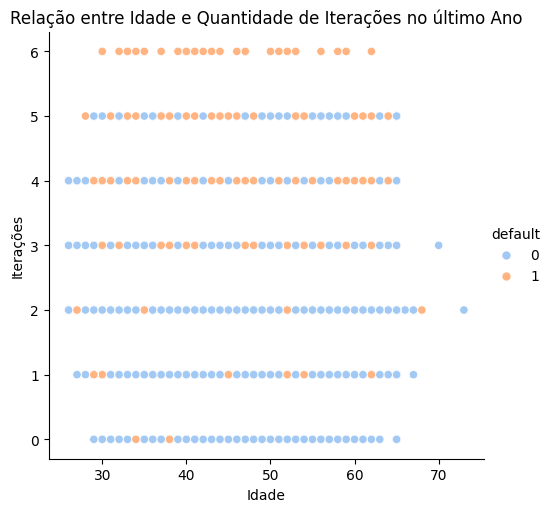

In [37]:
f = sns.relplot(x='idade', y='iteracoes_12m', data=df, hue='default')
_ = f.set(
    title='Relação entre Idade e Quantidade de Iterações no último Ano',
    xlabel='Idade',
    ylabel='Iterações'
  )



> Analisando idade vs quantidade iterações, identificamos que independente da idade, conforme maior o número de iterações, maior é a quantidade de clientes inadimplentes.









*  **Quantidade de Transações nos últimos 12 meses**








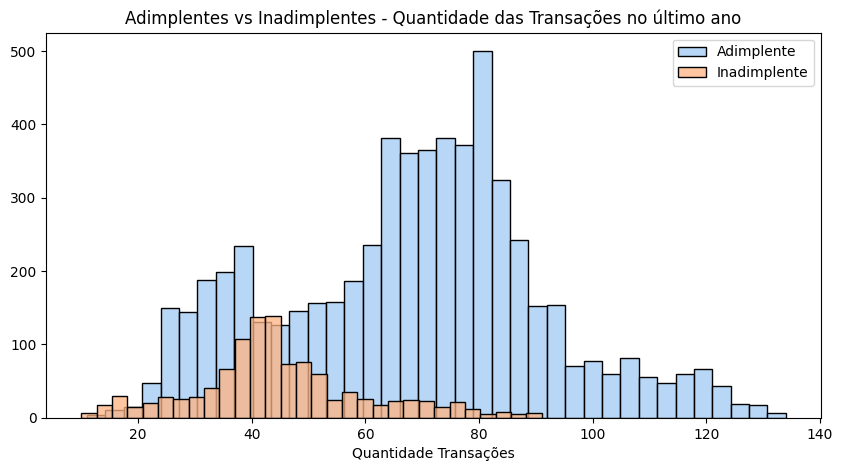

In [38]:
plt.figure(figsize=(10, 5))
plt.title('Adimplentes vs Inadimplentes - Quantidade das Transações no último ano')
sns.histplot(df_adimplente['qtd_transacoes_12m'], color='#A1C9F4', label='Adimplente', kde=False)
sns.histplot(df_inadimplente['qtd_transacoes_12m'], color='#FFB482', label='Inadimplente', kde=False)
plt.xlabel('Quantidade Transações')
plt.ylabel('')
plt.legend()
plt.show()


> Podemos observar no gráfico acima que a quantidade de transações é um fator relevante para o indicador de inadimplência. Devido ao número de transações serem relativamente menores do que os clientes adimplentes.





*   **Valor das Transações nos últimos 12 meses**



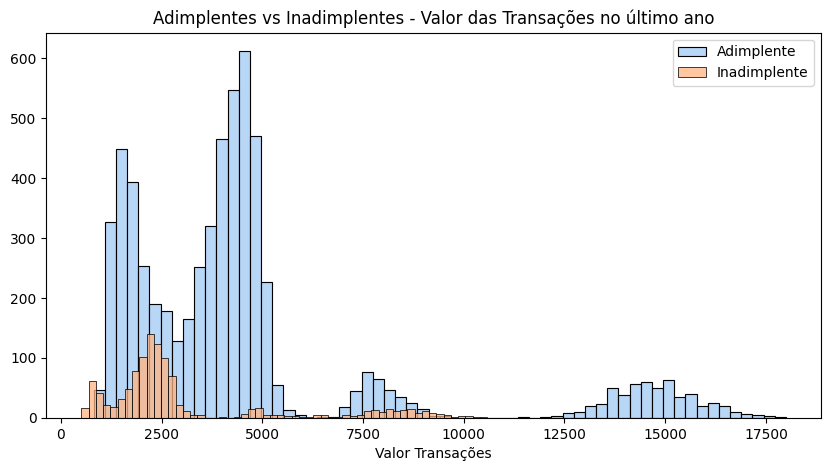

In [39]:
plt.figure(figsize=(10, 5))
plt.title('Adimplentes vs Inadimplentes - Valor das Transações no último ano')
sns.histplot(df_adimplente['valor_transacoes_12m'], color='#A1C9F4', label='Adimplente', kde=False)
sns.histplot(df_inadimplente['valor_transacoes_12m'], color='#FFB482', label='Inadimplente', kde=False)
plt.xlabel('Valor Transações')
plt.ylabel('')
plt.legend()
plt.show()


> O gráfico acima nos mostra que o valor das transações é um fator relevante para o indicador de inadimplência.
Observamos que o valor das transações dos clientes inadimplentes é consideravelmente menor do que os adimplentes.





*   **Valor das Transações nos últimos 12 meses vs Quantidade de Transações nos últimos 12 meses**




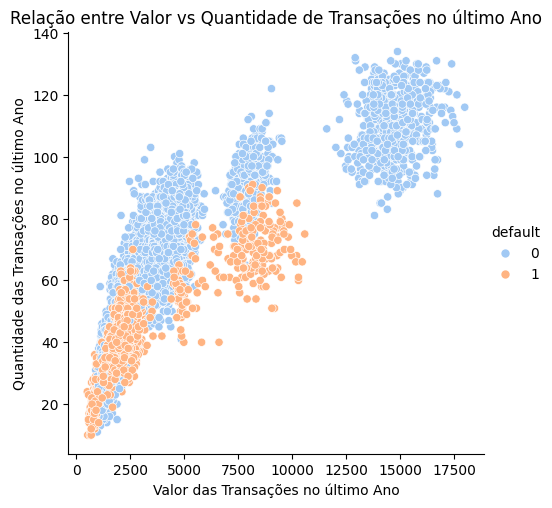

In [40]:
f = sns.relplot(x='valor_transacoes_12m', y='qtd_transacoes_12m', data=df, hue='default')
_ = f.set(
    title='Relação entre Valor vs Quantidade de Transações no último Ano',
    xlabel='Valor das Transações no último Ano',
    ylabel='Quantidade das Transações no último Ano'
  )


**Legenda:**
*   Cor Azul: Clientes Adimplentes
*   Cor Laranja: Clientes Inadimplentes





> Após correlacionar as duas variáveis, ficou claro que quanto maior o valor e a quantidade das transações, menor é a chance do cliente ser um inadimplente.
Os dados nos mostram que os clientes inadimplentes possuem valor e quantidade das transações baixas.



## **7. Resumo dos insights gerados**





Podemos concluir que os atributos categóricos não são capazes de definir algum comportamento de inadimplência ou adimplência. Porém, quando analisamos os atributos númericos, os seguintes itens se destacam:


*   ***Idade vs Quantidade Iterações***, identificamos que independente da idade, conforme maior o número de iterações, maior é a quantidade de clientes inadimplentes.

*   ***Quantidade de Transações nos últimos 12 meses***, observamos que a quantidade de transações é um fator relevante para o indicador de inadimplência. Devido ao número de transações serem relativamente menores do que os clientes adimplentes.

*   ***Valor das Transações nos últimos 12 meses***, os dados são claros que o valor das transações é um fator relevante para o indicador de inadimplência.
Observamos que o valor das transações dos clientes inadimplentes é consideravelmente menor do que os adimplentes.

*   ***Relação entre Valor vs Quantidade de Transações no último Ano***,
Após correlacionar as duas variáveis, ficou claro que quanto maior o valor e a quantidade das transações, menor é a chance do cliente ser um inadimplente. Os dados nos mostram que os clientes inadimplentes possuem valor e quantidade das transações baixas.







